# CVRIE

**UNSUPERVISED LEARNING**. Our goal is to be able to use a model from a dataset that can detect a category of disease from the symptoms recorded in the dataset.

## **DATA CLEANING**

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import string

## LOAD CSV FILE

First, we can retrieve our **Student_Dataset.csv** file so we can work with its data. We add names to the columns to better differentiate them. Finally, we remove any duplicates.
We can see two columns: one containing 0x00000 (colors) and symptoms, and another containing symptoms and null values. We therefore decided to combine the two columns of symptoms into a single column called VALUE.

In [50]:
data = pd.read_csv('Student_Dataset.csv', delimiter=',', names=['ID', 'SYMPTOM1', 'SYMPTOM2'])
data_clean = data.drop_duplicates().copy()

data_clean['VALUE'] = data_clean['SYMPTOM1']
data_clean.loc[data_clean['VALUE'] == "0x000000", 'VALUE'] = data_clean['SYMPTOM2']

print("Shape Csv : ")
print(data_clean.shape)
print("Types of columns : ")
print(data_clean.dtypes)

Shape Csv : 
(1011, 4)
Types of columns : 
ID          int64
SYMPTOM1      str
SYMPTOM2      str
VALUE         str
dtype: object


## Example of the first line 

In [51]:
print(data_clean.loc[0])

ID                                                          1
SYMPTOM1    On uneven paths the heel feels wobbly side‑to‑...
SYMPTOM2                                                  NaN
VALUE       On uneven paths the heel feels wobbly side‑to‑...
Name: 0, dtype: object


## **PRE PROCESSING**

## CLEAN STR 

**1**. ***Remove extra spaces***. This makes the text more readable and easier to encode.

**2**. ***Convert the words to lowercase***. This is like normalizing values ​​to make everything uniform.

**3**. ***Remove punctuation***. Here, punctuation isn't very useful, unlike in poetry, for example.

This will make it easier to encode text variables for algorithms.


In [52]:
print("Here are some symptom lines before the cleaning\n")
print("Column 1 : ", data_clean['VALUE'].loc[0])
print("Column 2 : ", data_clean['VALUE'].loc[1], "\n")

data_clean['VALUE'] = data_clean['VALUE'].str.lower()

data_clean['VALUE'] = data_clean['VALUE'].str.strip()

def replace_punctuation(list):
    sans_ponct = list.translate(str.maketrans("", "", string.punctuation))
    return sans_ponct
            
data_clean['VALUE'] = data_clean['VALUE'].apply(replace_punctuation)

def change_number(text):
    list_string_without_number = ""
    for word in text:
        if (not word.isdigit()):
            list_string_without_number += word
    return list_string_without_number
            
data_clean['VALUE'] = data_clean['VALUE'].apply(change_number)

print("Here are some symptom lines after the cleaning\n")
print("Column 1 : ", data_clean['VALUE'].loc[0])
print("Column 2 : ", data_clean['VALUE'].loc[1], "\n")

data_clean = data_clean.drop(columns='ID')

Here are some symptom lines before the cleaning

Column 1 :  On uneven paths the heel feels wobbly side‑to‑side. Slanted pavements bring a quick aching shift under the ankle when I step.
Column 2 :  The feverish feeling eased, but I’m now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can’t fill my lungs completely. 

Here are some symptom lines after the cleaning

Column 1 :  on uneven paths the heel feels wobbly side‑to‑side slanted pavements bring a quick aching shift under the ankle when i step
Column 2 :  the feverish feeling eased but i’m now breathing faster with a dry exhausting cough i get light‑headed after climbing stairs and feel like i can’t fill my lungs completely 



## Encode variables

Indeed, this is one of the most important processes because our variables, as they are, are not readable by our machine learning models. We will therefore need to do several things using **TfidfVectorizer**.

***1***. We will be able to tokenize our values, that is, create a list of words.

***2***. On va personaliser nos hyperparametrs afin de rendre la vectorisation la plus optimale. 

    -> We remove words **stop_words** that are not very useful, such as conjunctions (and, or, etc.).

    -> We limit the number of **max_features** to enclose the words used.

    -> The implementation of what are called bigrams with **nram_range** to create word combinations.

    -> We define the minimum number of times the word must appear.

***3***. We transform everything into a vector of values.

In [53]:
custom_stop_word = ['feel','feels','felt', 've', 'pain', 'ache', 'makes', 'feeling', 'gives', 'like', 'didnt', 'ive']
all_stop_word = list(ENGLISH_STOP_WORDS.union(custom_stop_word))
encode = TfidfVectorizer(stop_words=all_stop_word, max_features=5000, ngram_range = (1,2), min_df=2)
X = encode.fit_transform(data_clean['VALUE'])

print("Displays all vocabulary words:")
print(encode.get_feature_names_out())
print("\nThe shape of the encode variable, n_samples, n_features = nb_lines, n_unique_words")
print(X.shape)
print("\nFinalement cela nous donne une matrice sparse : ")
print(X)

Displays all vocabulary words:
['abdomen' 'able' 'accidentally' ... 'yesterday' 'yoga' 'zapping']

The shape of the encode variable, n_samples, n_features = nb_lines, n_unique_words
(1011, 2757)

Finalement cela nous donne une matrice sparse : 
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15661 stored elements and shape (1011, 2757)>
  Coords	Values
  (0, 2565)	0.1987638101790648
  (0, 1619)	0.2425146176733638
  (0, 1010)	0.1987638101790648
  (0, 2715)	0.21241348384615272
  (0, 2038)	0.2531931648398075
  (0, 1626)	0.2531931648398075
  (0, 236)	0.201734936679709
  (0, 1732)	0.1809624097869996
  (0, 8)	0.22174209078065443
  (0, 1952)	0.2425146176733638
  (0, 26)	0.16898129861111372
  (0, 2223)	0.201734936679709
  (0, 2568)	0.2425146176733638
  (0, 1620)	0.2531931648398075
  (0, 1011)	0.2531931648398075
  (0, 2039)	0.2531931648398075
  (0, 1627)	0.2531931648398075
  (0, 237)	0.2425146176733638
  (0, 1953)	0.2531931648398075
  (1, 765)	0.27041961515707447
  (1, 663)	0.3025

## **MODELS**

## FUNCTION FOR SHOW GRAPH : 

In [54]:
def show_graph(X, model):
    plt.figure(figsize=(10,6))
    plt.scatter(X[:,0], X[:,1], c=model.labels_, cmap='tab20', s=10)
    plt.title("Clusters")
    plt.show()

# Resize the sparse matrix

TruncatedSVD performs linear dimensionality reduction, similar to PCA, but compatible with sparse matrices. This is because Tfid Vectoriser returns a sparse matrix.

We use the truncated form for different reasons; here it will allow us to : 

Distances become more reliable in a confined space.

Reduce noise. 

Infrequent or irrelevant words have less weight.

In [55]:
svd = TruncatedSVD(n_components=50)
X_trunc = svd.fit_transform(X)

print("Matrix formatted by Truncated: ")
print(X_trunc)

Matrix formatted by Truncated: 
[[ 0.03617203 -0.05079537 -0.05511415 ...  0.06571534  0.01544923
  -0.00154425]
 [ 0.09979632  0.0277397   0.01109643 ...  0.00248731 -0.01346593
  -0.03958593]
 [ 0.07037337 -0.06277863  0.00490566 ...  0.08859775 -0.04446247
   0.00181425]
 ...
 [ 0.12200814  0.01934566  0.05024236 ... -0.02039412  0.02274763
   0.09367745]
 [ 0.08753397 -0.1202347  -0.13850548 ... -0.063573    0.01483846
   0.02316682]
 [ 0.12260186  0.0702157   0.02461064 ... -0.05060121 -0.00175474
   0.05915182]]


There are things we prefer in a 2D matrix, which is much easier to read and use.

## KMEAN

The goal of K-means is to partition a dataset into K clusters so that the elements of the same cluster are as similar as possible to each other and different from the elements of other clusters.

In the end, the data is divided into K clusters, each represented by a centroid, which corresponds to the average of the points belonging to that cluster.

## Searching number of clusters

Most clustering models require specifying the number of clusters beforehand. In other words, the model needs to know into how many groups (or labels) the data should be divided.

For example, a burn, a cut, and back pain represent three different types of conditions, so they could be separated into three different clusters. However, if we add a description such as “severe heat on the thumb”, it could reasonably be associated with the burn category. Therefore, it would belong to the same cluster or label as other burn-related descriptions.

This illustrates how clustering algorithms group similar descriptions together based on their textual features.

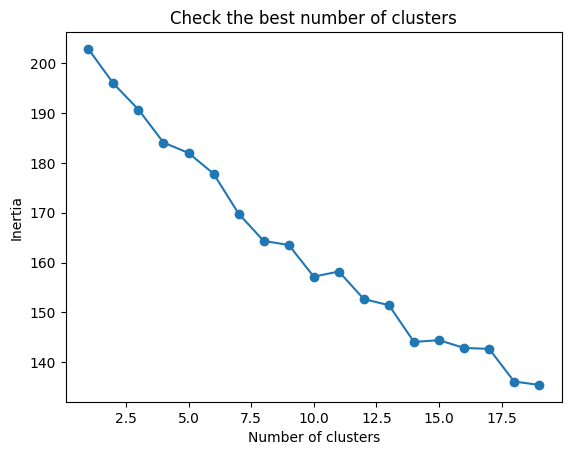

In [56]:
list_cluster = list(range(1, 20))

def found_cluster_number():
    inertie = []
    for i in list_cluster:
        kmeans = KMeans(init='k-means++', n_clusters=i).fit(X_trunc)
        inertie.append(kmeans.inertia_)
    return inertie

plt.plot(list_cluster, found_cluster_number(), marker='o')
plt.title('Check the best number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

Here, we look for the point where the curve bends (the elbow point). We determined that the curve bends around 8-9 clusters, which will therefore be the value used in our models.

### LAUNCH MODEL

In this section, we do three important things:

**1**. We launch the model with the appropriate number of clusters, which gives us the values ​​for each row of our dataset, linked to a value.

**2**. We use TSNE to resize our data so that we can use it with graphs.

**3**. The creation of a dataset containing the membership of each row in the cluster to which it is linked.

In [57]:
kmean = KMeans(init='k-means++', n_clusters=9, random_state=42)
clusters = kmean.fit_predict(X_trunc)

tsne = TSNE(n_components=2, random_state=42)
X_Kmean = tsne.fit_transform(X_trunc)

new_kmean_data = data_clean.copy()
new_kmean_data['CLUSTER'] = clusters

### Visualization of values

In [58]:
def most_commonly_used_words(kmeans, encoder, n_mots=5):
    for i, centre in enumerate(kmeans.cluster_centers_):
        index = centre.argsort()[-n_mots:][::-1]
        most_words = [encoder.get_feature_names_out()[i] for i in index]
        print(f"Cluster {i} : {', '.join(most_words)}")

print("Themes by words :")
most_commonly_used_words(kmean, encode, n_mots=10)

Themes by words :
Cluster 0 : abdomen, aching sensation, accidentally touched, air eased, allergic, aches, ankle inward, appears surface, achy, air
Cluster 1 : accompanied, abdomen, able, aches longer, accidentally touched, actual, active, allergic, allergy, appears
Cluster 2 : abdomen, aches longer, active, activities, ankle bone, anti dandruff, appeared, allergy, ankle aches, actual
Cluster 3 : aching sensation, actual, abdomen, achy, activity, active, actual diagnosis, ankle stepping, anti, ago
Cluster 4 : abdomen, accidentally, accompanied, aching, aches pushing, ahead, air, appears surface, appearing, actual diagnosis
Cluster 5 : aches, accidentally touched, aches pushing, abdomen, accidentally, active, activities, aches longer, activity, actual
Cluster 6 : abdomen, able, accidentally touched, aches, actual diagnosis, aching sensation, activities, aching, achy, aggravate
Cluster 7 : achy, aches pushing, activities, abdomen, accompanied, allergies, accidentally, ago, appear randoml

In [59]:
print("\nSilhouette score between (-1 and 1) : ")
print(silhouette_score(X_trunc, kmean.labels_))
print("\nNumber of values by cluster :")
print(new_kmean_data['CLUSTER'].value_counts())


Silhouette score between (-1 and 1) : 
0.07658323896312243

Number of values by cluster :
CLUSTER
4    371
2    263
6     83
0     64
1     59
5     57
8     52
3     44
7     18
Name: count, dtype: int64


#### Visualization graph

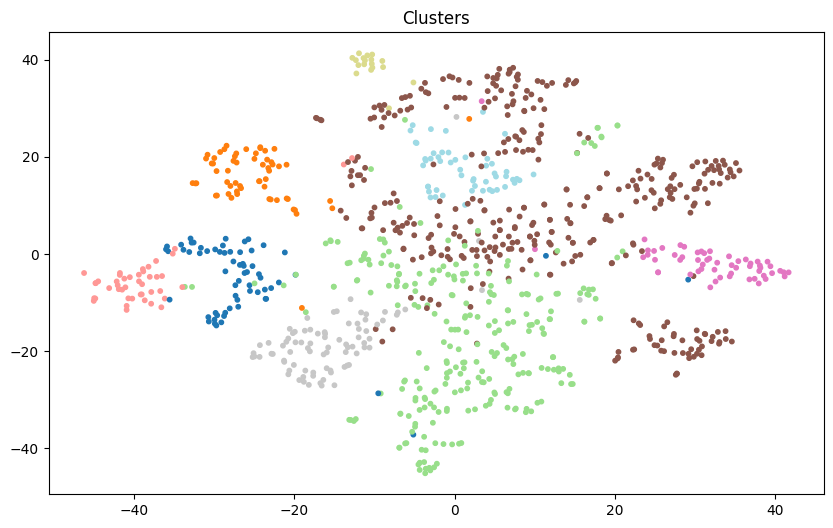

In [60]:
show_graph(X_Kmean, kmean)

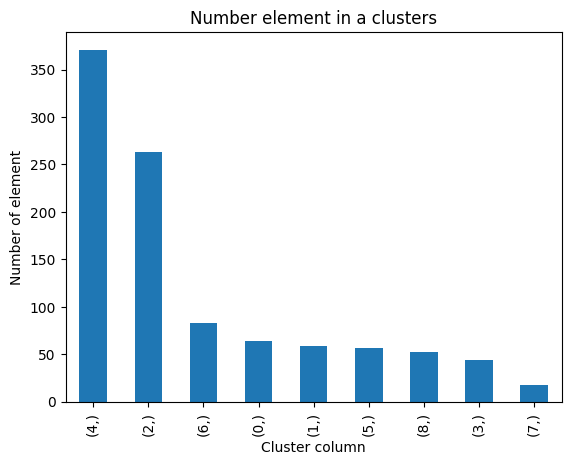

In [61]:
cluster_counts = pd.DataFrame(kmean.labels_).value_counts()
cluster_counts.plot(kind='bar')
plt.title('Number element in a clusters')
plt.xlabel("Cluster column")
plt.ylabel("Number of element")
plt.show()

### **Global Observation Kmean**: 

We can see that K-means is effective at detecting and distributing elements into clusters. However, we also observe that it makes several mistakes. This can be confirmed by the graph and the previously obtained values.

From a semantic point of view, the clustering seems relatively coherent, but the silhouette score indicates that the quality of the clustering still needs improvement. This suggests that the clusters are not well separated and may overlap.

One possible explanation is that K-means relies on strong assumptions. In particular, it assumes that clusters are spherical, of similar size, and evenly distributed. However, in our case, these assumptions do not hold. Our dataset contains around 1000 rows of symptom data, where the distribution is likely uneven and the relationships between variables are complex.

Moreover, symptom-based data often leads to irregular and non-linear structures, which K-means struggles to capture effectively. This can result in poorly defined cluster boundaries and lower overall performance.

K-means attempts to force balanced clusters, even if this isn't natural in the data.

This leads us to test models such as Agglomerative or DBSCAN.

# Launch MODEL Agglomerative Clustering

Hierarchical clustering is a clustering method that constructs a hierarchy of clusters.

Agglomerative: This is a bottom-up approach in which each observation is initially treated as its own cluster. Moving from the bottom up, each observation is merged into pairs, and the pairs are then merged into clusters.


## Searching number of clusters

Value when k = 2 : 0.08103248993208004
Value when k = 3 : 0.041994524517528595
Value when k = 4 : 0.04722078980955326
Value when k = 5 : 0.05237542498761066
Value when k = 6 : 0.061431585801167005
Value when k = 7 : 0.06505234118222943
Value when k = 8 : 0.07231225690094603
Value when k = 9 : 0.07876562612691773
Value when k = 10 : 0.08435132233857473
Value when k = 11 : 0.08655841119304142


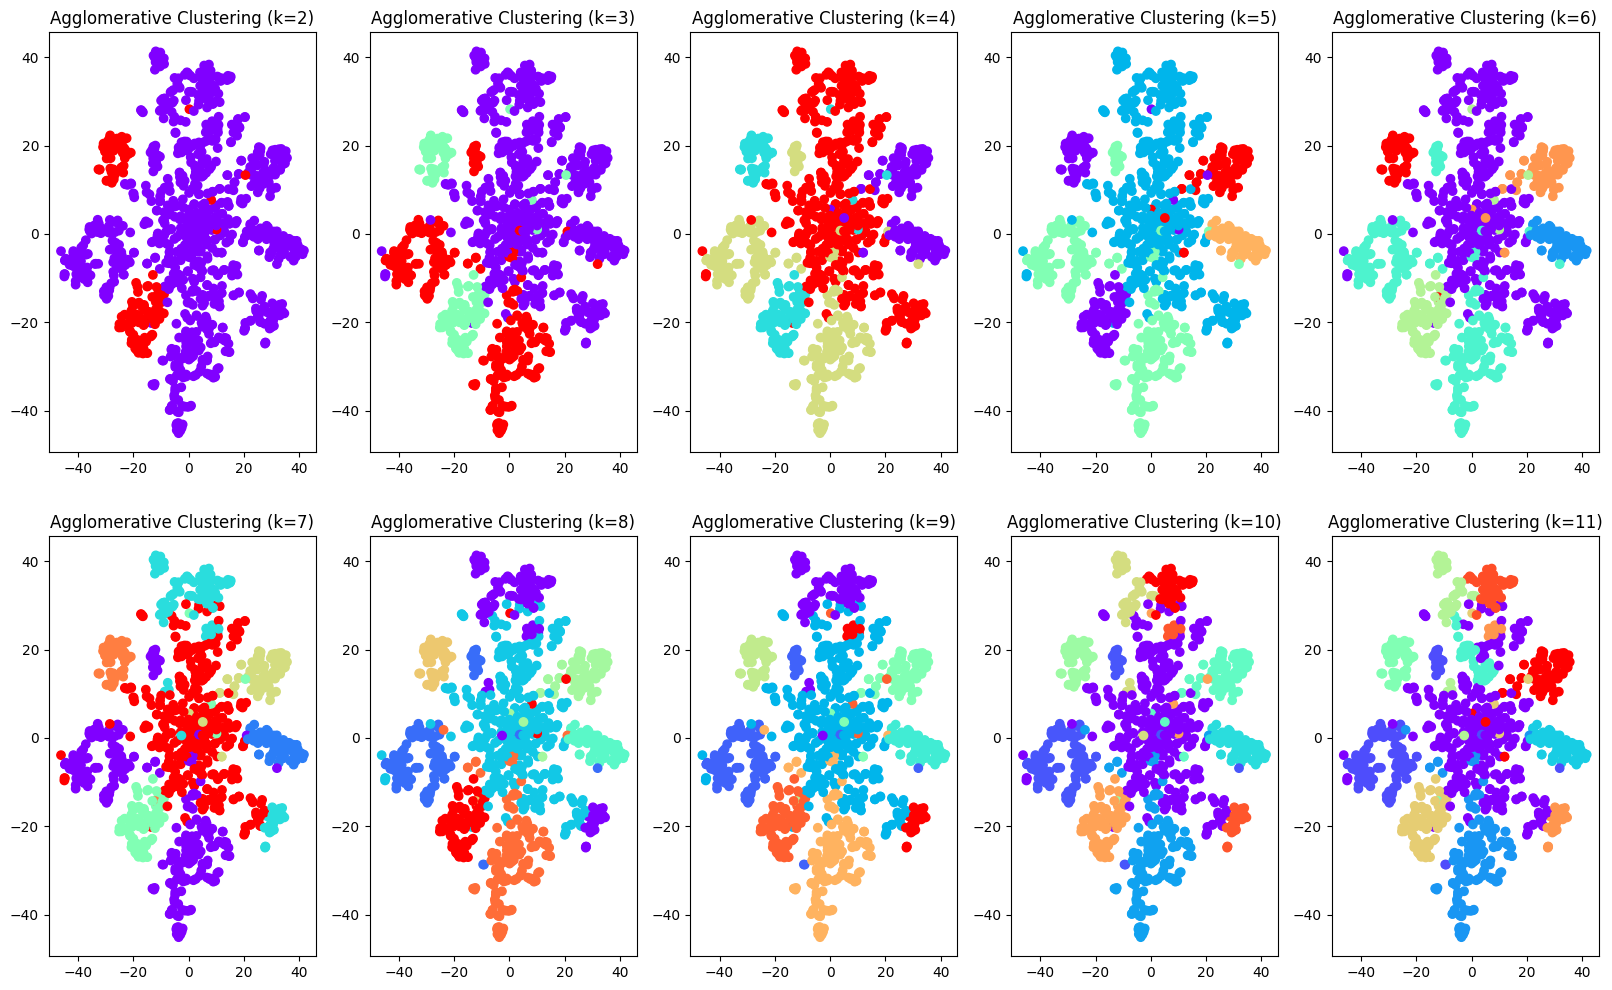

In [62]:
redim = TSNE(n_components=2, random_state=42)
X_Algo = redim.fit_transform(X_trunc)

fig, axes = plt.subplots(2, 5, figsize=(20, 12))
axes = axes.flatten()

for i,k in enumerate(range(2, 12)):
    agglo = AgglomerativeClustering(n_clusters=k)
    clusters = agglo.fit_predict(X_trunc)
    axes[i].scatter(X_Algo[:,0], X_Algo[:,1], c=clusters, cmap='rainbow')
    print(f"Value when k = {k} :", silhouette_score(X_trunc, agglo.labels_))
    axes[i].set_title(f'Agglomerative Clustering (k={k})')

plt.show()

Although k=2 maximizes the silhouette score, this choice produces clusters that are too general and difficult to interpret. A k between 8 and 11 offers a better compromise between separation quality and semantic coherence of the groups.

Here, we notice that the number of clusters leads us to choose 11 clusters with a silhouette score percentage of around 0.08

### LAUNCH MODEL

In this section, we do three important things:

**1**. We launch the model with the appropriate number of clusters, which gives us the values ​​for each row of our dataset, linked to a value.

**2**. We use TSNE to resize our data so that we can use it with graphs.

**3**. The creation of a dataset containing the membership of each row in the cluster to which it is linked.

In [63]:
agglomerativeclustering = AgglomerativeClustering(n_clusters=11)
clusters = agglomerativeclustering.fit_predict(X_trunc)

new_agglo_data = data_clean.copy()
new_agglo_data['CLUSTER'] = clusters

### Visualization of values

In [64]:
print("\nSilhouette score between (-1 and 1) : ")
print(silhouette_score(X_trunc, agglomerativeclustering.labels_))
print("\nNumber of values by cluster :")
print(new_agglo_data['CLUSTER'].value_counts())


Silhouette score between (-1 and 1) : 
0.08655841119304142

Number of values by cluster :
CLUSTER
0     316
2     145
1     118
7      81
10     76
3      60
5      48
6      47
9      45
4      38
8      37
Name: count, dtype: int64


### Visualization Graph

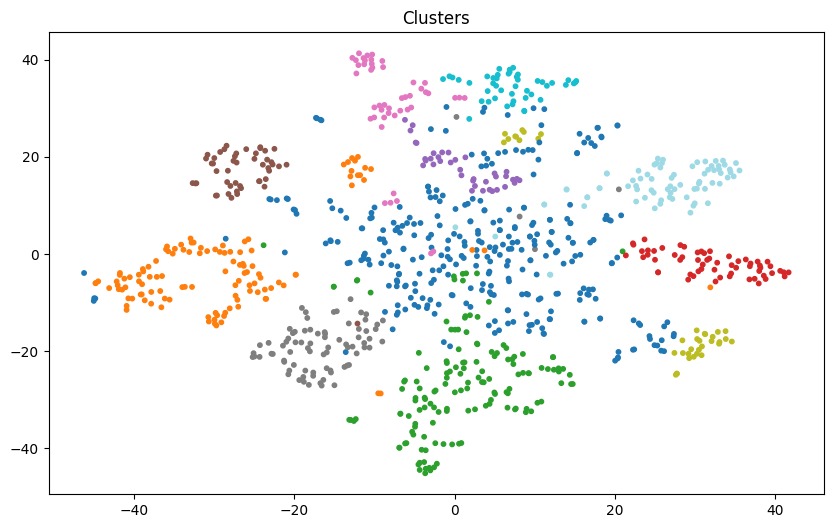

In [65]:
show_graph(X_Algo, agglomerativeclustering)

### **Global Observation Agglomerative :**

In our initial observations, we used the same number of clusters as for K-means, and then we verified the consistency of this choice using graph visualization.

We found that the silhouette score is the best, with a value of 0.164. This indicates better separation between clusters and a more consistent distribution of the data. The visualization also confirms this, showing more distinct and better-structured groups.

These results reveal that the algorithm better captures the underlying structure of the data. It manages to better represent the relationships between observations, despite the complexity and potential imbalance of the dataset.

Thus, this improved performance in terms of silhouette score and visualization shows that this approach is more suitable than K-means for our case study.

Agglomerative clustering adapts better to the actual structure:

    -> It accepts that some groups may be larger than others.

    -> It better captures complex relationships (very important for symptom analysis).


We'll test the dbscan last.

## DBSCAN

The algorithm works by defining a neighborhood around each data point and counting how many other points are within that neighborhood. Two main hyperparameters control this process, requiring careful tuning to match the specific characteristics of the data:

***Epsilon*** (eps): This parameter specifies the maximum radius around a point for searching for neighbors. It defines the "reachability" distance.

***Minimum*** Points (minPts): This option defines the minimum number of data points required within the epsilon radius to form a dense region or "core.



### SEARCH VALUE e

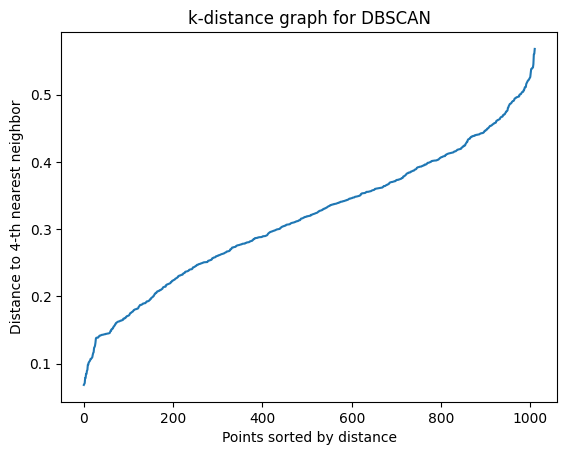

In [66]:
k = 4
nn = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X_trunc)
d, i = nn.kneighbors(X_trunc)
k_d = np.sort(d[:, k])

plt.plot(k_d)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {k}-th nearest neighbor")
plt.title("k-distance graph for DBSCAN")
plt.show()


We decided to use an epsilon of 0.35 at the curve's elbow. That is, the distance between the points for which we consider them to belong to a cluster.

### LAUNCH MODEL

In [67]:
dbscan = DBSCAN(eps=0.35, min_samples=5, metric='cosine')
cluster = dbscan.fit_predict(X_trunc)

redim = TSNE(n_components=2, random_state=42)
X_dbscan = redim.fit_transform(X_trunc)

new_dbscan_data = data_clean.copy()
new_dbscan_data['CLUSTER'] = dbscan.labels_

### Visualization of values

In [68]:
print("Here are the categories by symptom")
for i in range(8):
    print("\nCluster : ", i)
    print(new_dbscan_data['VALUE'][new_dbscan_data['CLUSTER']==i].head(3))    

Here are the categories by symptom

Cluster :  0
0    on uneven paths the heel feels wobbly side‑to‑...
1    the feverish feeling eased but i’m now breathi...
8    since i lost  pounds my headaches have lessene...
Name: VALUE, dtype: str

Cluster :  1
2    while working in the garden i touched a metal ...
4    i accidentally left my hand on a hot mug for a...
6    during a birthday party a hot beverage was kno...
Name: VALUE, dtype: str

Cluster :  2
7     i noticed a rash on my forearms after handling...
9     the rash on my face and jaw is a classic hives...
23    after eating lunch i noticed a rash on my arms...
Name: VALUE, dtype: str

Cluster :  3
Series([], Name: VALUE, dtype: str)

Cluster :  4
Series([], Name: VALUE, dtype: str)

Cluster :  5
Series([], Name: VALUE, dtype: str)

Cluster :  6
Series([], Name: VALUE, dtype: str)

Cluster :  7
Series([], Name: VALUE, dtype: str)


In [69]:
print("\nSilhouette score between (-1 and 1) : ")
print(silhouette_score(X_trunc, dbscan.labels_))
print("\nNumber of values by cluster :")
print(new_dbscan_data['CLUSTER'].value_counts())


Silhouette score between (-1 and 1) : 
-0.03289075069064746

Number of values by cluster :
CLUSTER
 0    676
-1    194
 2     74
 1     67
Name: count, dtype: int64


In [70]:
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = list(dbscan.labels_).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 3
Number of noise points: 194



This information is very interesting for seeing the "waste" produced by dbscan and the points considered as noise and therefore lost.

### Visualization graph

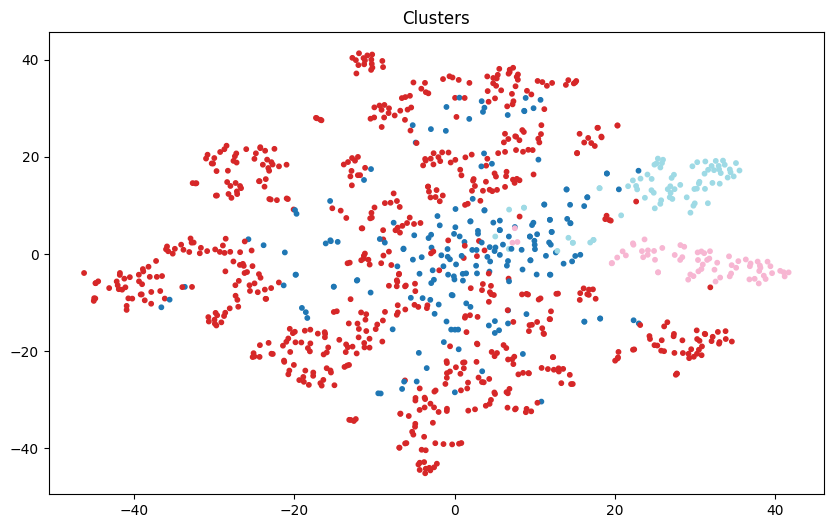

In [71]:
show_graph(X_dbscan, dbscan)

### **Global Observation DBSCAN** 

The DBSCAN model is not suitable for this textual dataset. Although it identifies 7 clusters, it considers more than 200 points as noise, which is too high for practical use. DBSCAN works better on dense and continuous data (e.g., geographic data), while dispersed textual data is better suited to hierarchical algorithms like Agglomerative Clustering.

The use of DBSCAN has reinforced our belief that models based on less dense and more dispersed data, such as K-Means or agglomerative models, are the best choices for this type of dataset.

## Export DATA with cluster

Depending on the model chosen, data can be exported with clusters.

In [72]:
# new_kmean_data.to_csv('kmean_data.csv')
new_agglo_data.to_csv('agglo_data.csv')
# new_dbscan_data.to_csv('dbscan_data.csv')

# CONCLUSION AND INSIGHT

Throughout this Jupyter Notebook, we explored the process of clustering textual data, covering several essential aspects of Natural Language Processing (NLP) and modeling.

We learned to:

Preprocess textual data: by applying techniques such as text encoding (vectorization) and stop word management.

Use different clustering models: including K-Means, Agglomerative Clustering, and DBSCAN, experimenting with their characteristics and analyzing their results.

We therefore had to consider:
How to choose the right clustering model based on the data and the task at hand.
Why some models perform better than others: for example, depending on the data structure, its density, or the presence of noise.


#### After testing several clustering models, we chose **Agglomerative Clustering** as the most appropriate model for this task. This decision was motivated by several considerations related to the characteristics of our data and the performance of the models.

1.**Data Nature**:
Our textual data, particularly medical symptoms, is often irregular and does not follow a simple geometric shape. The K-Means model, which relies on minimizing the distance between points and cluster centers (centroids), performs particularly well when clusters use relatively simple data. However, in the case of our data, the clusters may be irregularly shaped or have hierarchical structures that are not well-suited to the K-Means method.

2.**Silhouette Score**:
When comparing Silhouette scores, Agglomerative Clustering produced higher results than K-Means for several values ​​of k. The Silhouette Score is an indicator of the internal cohesion and separation of clusters. A higher score indicates that the clusters are well-separated and consistent.

3.**Cluster Consistency**:
The clusters generated by Agglomerative Clustering were semantically more consistent compared to those produced by K-Means. Agglo's hierarchical approach allows for the capture of subtle relationships between observations, which is essential for data such as medical symptoms, where texts may be similar but slightly different.